In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load dataset
df = pd.read_csv("googleplaystore_user_reviews.csv")

# Display first 5 rows
df.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


In [3]:
# Dataset Shape
print("Dataset Shape:", df.shape)

# Dataset Information
df.info()

Dataset Shape: (64295, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64295 entries, 0 to 64294
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   App                     64295 non-null  object 
 1   Translated_Review       37427 non-null  object 
 2   Sentiment               37432 non-null  object 
 3   Sentiment_Polarity      37432 non-null  float64
 4   Sentiment_Subjectivity  37432 non-null  float64
dtypes: float64(2), object(3)
memory usage: 2.5+ MB


In [4]:
# Check missing values
df.isnull().sum()

,0
App,0
Translated_Review,26868
Sentiment,26863
Sentiment_Polarity,26863
Sentiment_Subjectivity,26863


In [5]:
# Check missing values
print(df.isnull().sum())

App                           0
Translated_Review         26868
Sentiment                 26863
Sentiment_Polarity        26863
Sentiment_Subjectivity    26863
dtype: int64


In [6]:
# Remove missing values
df = df.dropna()

# Check dataset shape after cleaning
print("Dataset Shape after removing missing values:", df.shape)

Dataset Shape after removing missing values: (37427, 5)


In [7]:
# Select required columns
df = df[['Translated_Review', 'Sentiment']]

# Display first 5 rows
df.head()

,Translated_Review,Sentiment
0,I like eat delicious food. That's I'm cooking ...,Positive
1,This help eating healthy exercise regular basis,Positive
3,Works great especially going grocery store,Positive
4,Best idea us,Positive
5,Best way,Positive


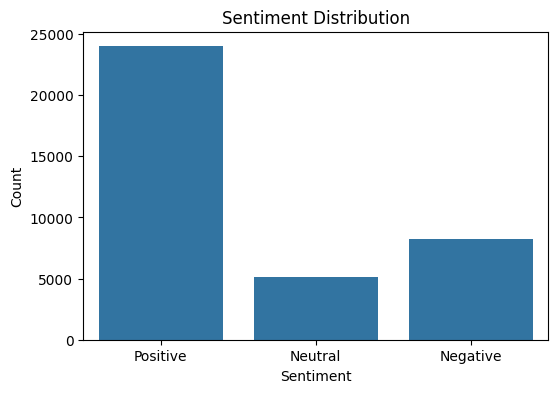

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(x='Sentiment', data=df)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()

In [9]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Sentiment'] = le.fit_transform(df['Sentiment'])

df.head()

,Translated_Review,Sentiment
0,I like eat delicious food. That's I'm cooking ...,2
1,This help eating healthy exercise regular basis,2
3,Works great especially going grocery store,2
4,Best idea us,2
5,Best way,2


In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Features (Review Text)
X = df['Translated_Review']

# Target (Sentiment)
y = df['Sentiment']

# Convert text into TF-IDF features
tfidf = TfidfVectorizer(stop_words='english')

X = tfidf.fit_transform(X)

print("TF-IDF Shape:", X.shape)

TF-IDF Shape: (37427, 20823)


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (29941, 20823)
Testing Data: (7486, 20823)


In [12]:
from sklearn.naive_bayes import MultinomialNB

# Create Model
model = MultinomialNB()

# Train Model
model.fit(X_train, y_train)

print("Model Trained Successfully!")

Model Trained Successfully!


In [13]:
# Predict sentiments
y_pred = model.predict(X_test)

print("Prediction Completed Successfully!")

Prediction Completed Successfully!


In [14]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", round(accuracy * 100, 2), "%")

Model Accuracy: 68.96 %


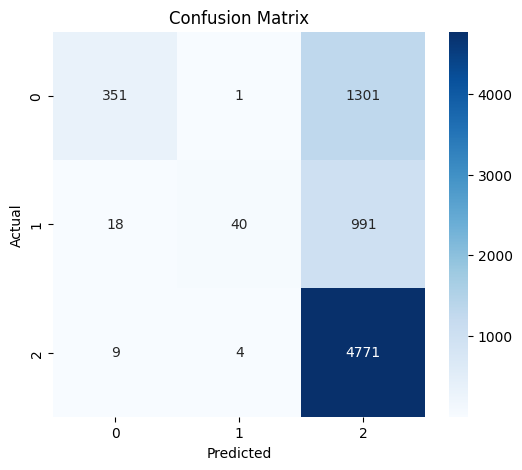

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [16]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.21      0.35      1653
           1       0.89      0.04      0.07      1049
           2       0.68      1.00      0.81      4784

    accuracy                           0.69      7486
   macro avg       0.83      0.42      0.41      7486
weighted avg       0.76      0.69      0.60      7486



In [17]:
# Function to predict sentiment
def predict_sentiment(review):
    review_vector = tfidf.transform([review])
    prediction = model.predict(review_vector)[0]

    # Convert numeric label back to sentiment
    sentiment = le.inverse_transform([prediction])[0]

    return sentiment

In [18]:
# Test the model with a custom review

review = "This app is very useful and easy to use."

result = predict_sentiment(review)

print("Review:", review)
print("Predicted Sentiment:", result)

Review: This app is very useful and easy to use.
Predicted Sentiment: Positive


In [19]:
print(predict_sentiment("Excellent app. I love using it every day."))
print(predict_sentiment("Worst application ever. It keeps crashing."))
print(predict_sentiment("The app is okay, nothing special."))

Positive
Negative
Positive
